# Univariate LSTM model with full input (no PCA)

**Directly predict *near-term* volatility from the full set of features.**

Author: Pete King

Here again we train a LSTM model to predict near-term volatility for a single ETF, but this time we use all features available in the dataset.

The purpose of this notebook is to explore how well the model adapts to a large amount of additional features, compared to our original test using very limited input (returns and historical volatility), and later to an expanded but still limited set of extracted features the we developed using PCA.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 21  # No. observations in each input sequence to LSTM
BATCH_SIZE = 5  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_vol_target']
train_df[data_cols + label_col]

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff,SPY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2015-10-22,0.000000,0.001704,-0.000358,0.000351,0.001018,0.008755,0.002129,0.020164,0.016753,0.003416,...,0.000588,0.020549,0.007308,0.012288,0.015393,0.006637,0.007860,0.008582,-0.0050,0.008038
2015-10-23,0.000000,-0.002557,-0.001703,0.003501,-0.005659,0.009802,-0.003664,0.027598,0.010902,-0.001437,...,0.000643,0.021230,0.006637,0.009267,0.020494,0.007144,0.008588,0.009448,0.0580,0.007682
2015-10-26,-0.000219,0.001097,-0.000628,-0.001049,0.002601,-0.006843,0.001791,0.000621,-0.002461,-0.000270,...,0.000639,0.014019,0.006290,0.009302,0.038293,0.006919,0.008600,0.008660,-0.0250,0.007669
2015-10-27,0.000000,0.000244,0.002241,-0.003271,0.002503,-0.011011,0.000255,0.002036,-0.001934,0.002246,...,0.000639,0.014824,0.006285,0.008545,0.038283,0.007235,0.008362,0.008474,-0.0300,0.007657
2015-10-28,0.000000,-0.002804,-0.008091,0.002688,-0.005197,0.028756,-0.003925,0.008278,0.011310,-0.005037,...,0.000614,0.024452,0.005689,0.007694,0.039257,0.007203,0.009030,0.008559,0.0640,0.007253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,0.000000,0.000000,0.000858,-0.001997,-0.000309,0.002104,0.001021,-0.006600,-0.000224,-0.000930,...,0.000764,0.024814,0.004327,0.014743,0.036885,0.004887,0.006989,0.016483,-0.0075,0.012897
2022-11-28,0.000109,-0.001241,-0.007935,-0.010588,0.000412,-0.020359,-0.007264,-0.014782,-0.016086,-0.002329,...,0.000718,0.022503,0.004753,0.012602,0.039479,0.003977,0.008063,0.016381,0.0120,0.012706
2022-11-29,0.000327,-0.003732,0.004928,0.004302,-0.004229,0.002910,-0.004966,-0.007598,-0.001719,-0.004299,...,0.000657,0.022514,0.004985,0.012653,0.045750,0.004235,0.007599,0.019170,0.0450,0.013284


In [3]:
val_df[data_cols + label_col]

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff,SPY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,0.000110,0.005276,0.008336,0.001900,0.007800,-0.005521,0.006900,-0.006783,-0.004219,0.003564,...,0.000879,0.020851,0.009018,0.008023,0.075598,0.007644,0.010158,0.012124,-0.086,0.011025
2023-01-04,-0.000110,0.005661,0.009368,0.011456,0.007637,0.012380,0.007227,0.004753,0.007691,0.000655,...,0.000848,0.026809,0.009284,0.008130,0.066839,0.007651,0.010032,0.015641,-0.084,0.011143
2023-01-05,0.000328,-0.001102,-0.012530,-0.002012,-0.001440,-0.010767,-0.000748,-0.015778,-0.011479,0.000281,...,0.000950,0.026784,0.008439,0.010383,0.069990,0.007900,0.010689,0.015555,0.011,0.010940
2023-01-06,-0.000109,0.010966,0.018535,0.014134,0.012787,0.022207,0.016245,0.027227,0.022673,0.009124,...,0.001502,0.025225,0.009823,0.012735,0.069995,0.006386,0.011978,0.015543,-0.151,0.010161
2023-01-09,0.000219,0.002723,0.002243,0.003568,0.002538,0.001688,0.003952,0.006452,-0.000567,0.002314,...,0.001522,0.025283,0.008534,0.014779,0.068986,0.006361,0.011061,0.014328,-0.052,0.010439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.000109,-0.001071,0.003184,-0.002017,-0.001228,0.000318,-0.001249,-0.009756,-0.002387,0.000091,...,0.001421,0.022678,0.008983,0.011213,0.032364,0.005283,0.009435,0.009005,0.011,0.008510
2024-08-27,0.000218,0.000000,0.002703,0.000631,-0.000410,-0.007787,-0.000804,0.002983,0.001372,0.000000,...,0.001344,0.022995,0.008969,0.011205,0.032928,0.005206,0.007833,0.009032,0.015,0.008549
2024-08-28,0.000109,-0.000670,-0.007052,-0.000505,-0.000512,-0.006789,-0.002057,-0.011412,-0.005822,-0.000091,...,0.001344,0.022711,0.008463,0.012903,0.031574,0.004901,0.007968,0.009530,0.008,0.008460


## II. PyTorch Multivariate LSTM Model

### Create Datasets and DataLoaders

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([21, 108])
Shape of first training label: torch.Size([1])


In [6]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 21, 108])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

Here we increase the number of neurons in the hidden layer to allow the model to capture more complex relationships in the input data.  This could lead to overfitting if we set it too high.

In [7]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 128  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [8]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [9]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(108, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [10]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [11]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.0010777913266792893
Validation loss: 0.005315452814102173
Epoch 20
Training loss:   0.003936148714274168
Validation loss: 0.005972551181912422
Epoch 30
Training loss:   0.0022251761984080076
Validation loss: 0.007650675252079964
Epoch 40
Training loss:   0.0028802226297557354
Validation loss: 0.0010058730840682983
Epoch 50
Training loss:   0.004546312615275383
Validation loss: 0.005702612921595573
Epoch 60
Training loss:   0.002463660668581724
Validation loss: 0.0008594542741775513
Epoch 70
Training loss:   0.0018851570785045624
Validation loss: 0.0031439457088708878
Epoch 80
Training loss:   0.002797973807901144
Validation loss: 0.005193920806050301
Epoch 90
Training loss:   0.007635843008756638
Validation loss: 0.010085895657539368
Epoch 100
Training loss:   0.0028914758004248142
Validation loss: 0.0022412706166505814


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


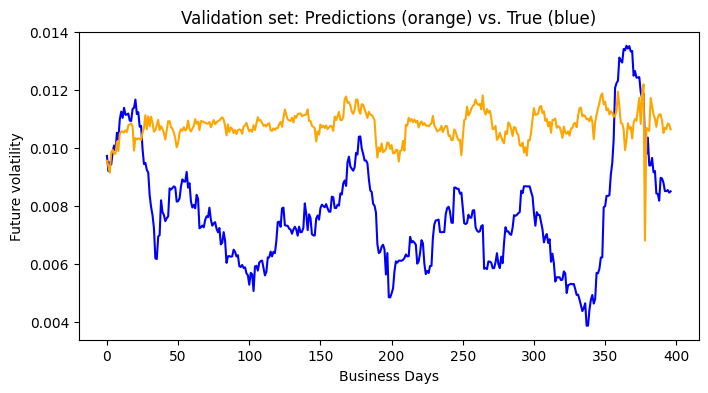

In [12]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds), color='orange')

The full set of features appears to have introduced too much noise -- the model behaves much less consistently than in the case with limited input.

In [13]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds))}')

R2: -2.537870168685913
MAE: 0.0032846592366695404
RMSE: 0.00360820977948606
MSE: 1.3019178368267603e-05
